# MLDS 2026 — Assignment 2
## PCA + Multi-Label Classification + Semantic Segmentation


In [1]:
import os, sys, json, math, random, time, shutil
from pathlib import Path

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms as T
from torchvision import models as tvm
from torchvision.models import resnet50, ResNet50_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── deterministic everything ──
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
torch.use_deterministic_algorithms(True, warn_only=True)

def seed_worker(worker_id):
    s = SEED + worker_id
    np.random.seed(s); random.seed(s)

g = torch.Generator()
g.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device, '| Torch:', torch.__version__)


Device: cuda | Torch: 2.10.0+cu128


In [ ]:
DATA_ROOT = Path('Dataset')
TRAIN_DIR = DATA_ROOT / 'train'
TEST_DIR  = DATA_ROOT / 'test'
TRAIN_IMG = TRAIN_DIR / 'images'
TRAIN_MSK = TRAIN_DIR / 'segmentation_masks'
TEST_IMG  = TEST_DIR  / 'images'
LABELS_CSV = TRAIN_DIR / 'labels.csv'

OUT_DIR = Path.cwd()
CLS_DIR = OUT_DIR / 'classification'
SEG_DIR = OUT_DIR / 'segmentation'
CLS_W   = CLS_DIR / 'weights'
SEG_W   = SEG_DIR / 'weights'
for d in (CLS_W, SEG_W): d.mkdir(parents=True, exist_ok=True)

CLASSES = ['aeroplane','bicycle','bird','boat','bottle','bus','car','cat',
           'chair','cow','diningtable','dog','horse','motorbike','person',
           'pottedplant','sheep','sofa','train','tvmonitor']
NUM_CLASSES = 20
SEG_CLASSES = 21
IGNORE_IDX  = 255

MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

IMG_SIZE_CLS = 224
IMG_SIZE_SEG = 384
BATCH_CLS    = 32
BATCH_SEG    = 8
EPOCHS_CLS   = 40
EPOCHS_SEG   = 50
LR_SEG       = 3e-4

print('DATA_ROOT:', DATA_ROOT.resolve())


DATA_ROOT: /kaggle/input/competitions/mlds-2026-assignment-2/Dataset


---
## Part 1 — PCA using NumPy (from scratch)


In [3]:
from skimage.io import imread
from skimage.transform import resize as sk_resize

def load_images_for_pca(img_dir, size=32, limit=None):
    files = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    if limit: files = files[:limit]
    X = np.zeros((len(files), size*size*3), dtype=np.float32)
    for i, f in enumerate(files):
        img = imread(str(Path(img_dir)/f))
        if img.ndim == 2: img = np.stack([img]*3, -1)
        if img.shape[-1] == 4: img = img[..., :3]
        X[i] = sk_resize(img, (size, size, 3), anti_aliasing=True).astype(np.float32).reshape(-1)
    return X, files

PCA_SIZE = 32
X_pca, _ = load_images_for_pca(TRAIN_IMG, size=PCA_SIZE)
print('X_pca:', X_pca.shape)


X_pca: (2200, 3072)


In [4]:
class PCA_NumPy:
    """PCA from scratch (SVD)."""
    def __init__(self, n_components): self.n_components = n_components
    def fit(self, X):
        self.mean_ = X.mean(0)
        U, S, Vt = np.linalg.svd(X - self.mean_, full_matrices=False)
        var = S**2 / (X.shape[0]-1)
        self.components_ = Vt[:self.n_components]
        self.explained_variance_ = var[:self.n_components]
        self.explained_variance_ratio_ = var[:self.n_components] / var.sum()
        return self
    def transform(self, X): return (X - self.mean_) @ self.components_.T
    def inverse_transform(self, Z): return Z @ self.components_ + self.mean_


k=  5 -> cum var 54.64%
k= 10 -> cum var 66.25%
k= 20 -> cum var 75.67%
k= 50 -> cum var 85.88%
k=100 -> cum var 91.67%
k=200 -> cum var 95.85%


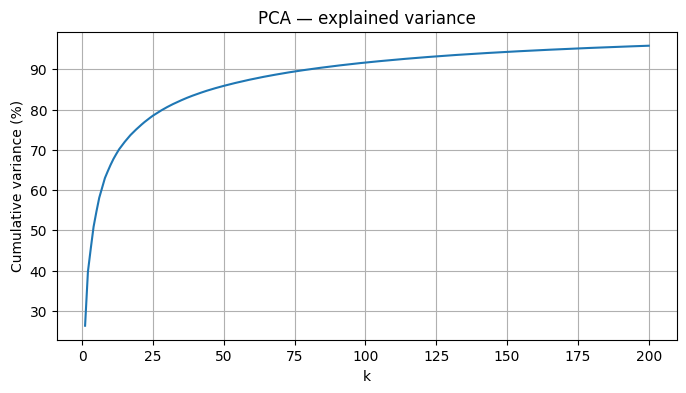

In [5]:
pca_full = PCA_NumPy(200).fit(X_pca)
cum = np.cumsum(pca_full.explained_variance_ratio_)
for k in [5,10,20,50,100,200]:
    if k <= len(cum): print(f'k={k:3d} -> cum var {cum[k-1]*100:.2f}%')
plt.figure(figsize=(8,4))
plt.plot(range(1,201), cum*100); plt.xlabel('k'); plt.ylabel('Cumulative variance (%)')
plt.title('PCA — explained variance'); plt.grid(True); plt.show()


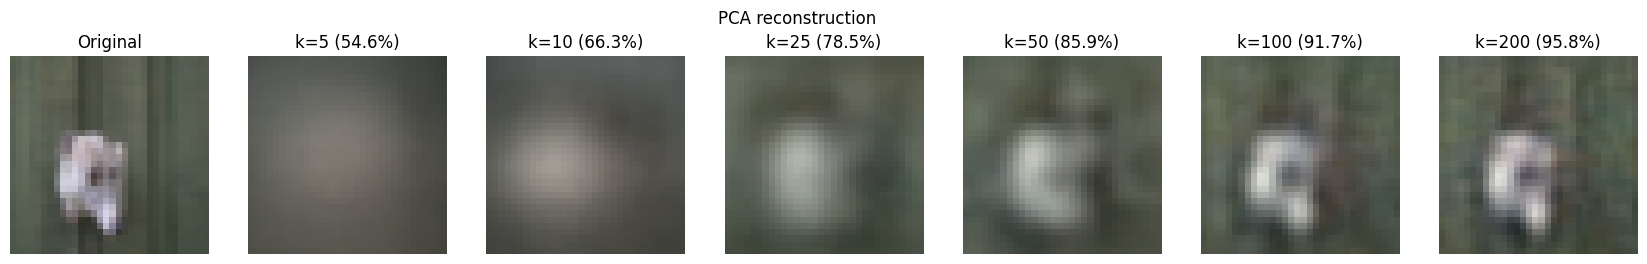

In [6]:
ks = [5,10,25,50,100,200]
fig, ax = plt.subplots(1, len(ks)+1, figsize=(3*(len(ks)+1), 3))
ax[0].imshow(X_pca[0].reshape(PCA_SIZE,PCA_SIZE,3).clip(0,1)); ax[0].set_title('Original'); ax[0].axis('off')
for i, k in enumerate(ks):
    p = PCA_NumPy(k).fit(X_pca)
    r = p.inverse_transform(p.transform(X_pca[:1])).reshape(PCA_SIZE,PCA_SIZE,3).clip(0,1)
    ax[i+1].imshow(r); ax[i+1].set_title(f'k={k} ({p.explained_variance_ratio_.sum()*100:.1f}%)'); ax[i+1].axis('off')
plt.suptitle('PCA reconstruction'); plt.show()


k=   2 | MSE=0.03539 | var kept=39.72%
k=   5 | MSE=0.02663 | var kept=54.64%
k=  10 | MSE=0.01981 | var kept=66.25%
k=  20 | MSE=0.01428 | var kept=75.67%
k=  40 | MSE=0.00956 | var kept=83.71%
k=  80 | MSE=0.00589 | var kept=89.97%
k= 160 | MSE=0.00312 | var kept=94.68%
k= 320 | MSE=0.00131 | var kept=97.78%
k= 640 | MSE=0.00035 | var kept=99.41%


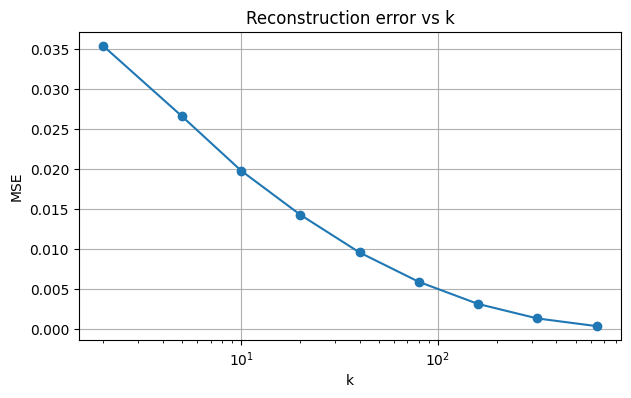

In [7]:
errs = []
for k in [2,5,10,20,40,80,160,320,640]:
    if k > min(X_pca.shape): continue
    p = PCA_NumPy(k).fit(X_pca)
    Xr = p.inverse_transform(p.transform(X_pca))
    errs.append((k, float(((X_pca-Xr)**2).mean()), float(p.explained_variance_ratio_.sum())))
    print(f'k={k:4d} | MSE={errs[-1][1]:.5f} | var kept={errs[-1][2]*100:.2f}%')
plt.figure(figsize=(7,4)); plt.plot([e[0] for e in errs], [e[1] for e in errs], 'o-')
plt.xscale('log'); plt.xlabel('k'); plt.ylabel('MSE'); plt.title('Reconstruction error vs k'); plt.grid(True); plt.show()


### Part 1 — Observations

* ~100 components capture >90% of variance — natural images are heavily redundant.
* Reconstructions at k=25 retain coarse shape/colour; k=100-200 is visually near-identical.
* The MSE curve shows a clear elbow near k=100, confirming strong diminishing returns.
* PCA is linear, so high-freq textures/edges are the first lost — expected.


---
## Part 2 — Data loading


In [8]:
labels_df = pd.read_csv(LABELS_CSV).sort_values('image_id').reset_index(drop=True)
all_ids = labels_df['image_id'].tolist()
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(all_ids))
n_val = int(0.15*len(all_ids))
val_set = set([all_ids[i] for i in perm[:n_val]])
train_ids = [i for i in all_ids if i not in val_set]
val_ids   = [i for i in all_ids if i in val_set]
label_lookup = {row['image_id']: row[CLASSES].values.astype(np.float32) for _, row in labels_df.iterrows()}
print(f'train={len(train_ids)} val={len(val_ids)}')


train=1870 val=330


---
## Part 2A — Multi-label Classification

**Architecture:** ResNet-50 (IMAGENET1K_V2) backbone + custom head:
`Dropout(0.5) → Linear(2048,512) → BN → ReLU → Dropout(0.3) → Linear(512,20) → Sigmoid`

**Training:** Single-phase with discriminative LRs (backbone 5e-5, head 1e-3), cosine schedule, `BCELoss`.

**Transforms:** `torchvision.transforms` (Resize, RandomHorizontalFlip, ColorJitter).


In [9]:
# ---------- Classification Dataset (torchvision transforms) ----------
class ClfDataset(Dataset):
    def __init__(self, img_dir, label_csv, ids, is_train):
        self.img_dir  = Path(img_dir)
        self.is_train = is_train
        df = pd.read_csv(str(label_csv), index_col='image_id')
        self.ids    = [i for i in ids if i in df.index]
        self.labels = df.loc[self.ids, CLASSES].values.astype(np.float32)
        self.train_tf = T.Compose([
            T.Resize((IMG_SIZE_CLS, IMG_SIZE_CLS)),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
            T.ToTensor(),
            T.Normalize(mean=MEAN, std=STD),
        ])
        self.val_tf = T.Compose([
            T.Resize((IMG_SIZE_CLS, IMG_SIZE_CLS)),
            T.ToTensor(),
            T.Normalize(mean=MEAN, std=STD),
        ])
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        img = Image.open(self.img_dir / f'{self.ids[idx]}.jpg').convert('RGB')
        tf  = self.train_tf if self.is_train else self.val_tf
        return tf(img), torch.tensor(self.labels[idx])

clf_tr = DataLoader(ClfDataset(TRAIN_IMG, LABELS_CSV, train_ids, is_train=True),
                    batch_size=BATCH_CLS, shuffle=True, num_workers=2, pin_memory=True,
                    worker_init_fn=seed_worker, generator=g)
clf_va = DataLoader(ClfDataset(TRAIN_IMG, LABELS_CSV, val_ids, is_train=False),
                    batch_size=BATCH_CLS, shuffle=False, num_workers=2, pin_memory=True,
                    worker_init_fn=seed_worker, generator=g)
print(f'Clf loaders: train={len(clf_tr)} batches, val={len(clf_va)} batches')


Clf loaders: train=59 batches, val=11 batches


In [10]:
# ---------- Classification Model ----------
class ClfHead(nn.Module):
    """Custom multi-label head."""
    def __init__(self, in_f=2048, hidden=512, n=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_f, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden, n),
        )
    def forward(self, x): return torch.sigmoid(self.net(x))

class ClfModel(nn.Module):
    """ResNet-50 backbone + custom ClfHead. Sigmoid output -> use BCELoss."""
    def __init__(self, pretrained=True):
        super().__init__()
        w  = tvm.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        bb = tvm.resnet50(weights=w)
        self.backbone = nn.Sequential(*list(bb.children())[:-1])   # (B,2048,1,1)
        self.head     = ClfHead()
    def forward(self, x):
        return self.head(self.backbone(x).flatten(1))

model_cls = ClfModel(pretrained=True).to(device)
total     = sum(p.numel() for p in model_cls.parameters())
print(f'ClfModel: {total/1e6:.1f}M params')


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s] 


ClfModel: 24.6M params


In [11]:
# ---------- Train Classification (single-phase, discriminative LRs) ----------
def per_image_f1(preds_np, labels_np, thr=0.5):
    pb = (preds_np >= thr).astype(np.float32)
    f1s = []
    for p, gt in zip(pb, labels_np):
        tp = (p*gt).sum(); fp = (p*(1-gt)).sum(); fn = ((1-p)*gt).sum()
        d  = 2*tp + fp + fn
        f1s.append(2*tp/d if d > 0 else 0.0)
    return float(np.mean(f1s))

def train_clf_epoch(model, loader, crit, opt):
    model.train(); tot = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        opt.zero_grad()
        loss = crit(model(imgs), labels)
        loss.backward(); opt.step()
        tot += loss.item() * imgs.size(0)
    return tot / len(loader.dataset)

@torch.no_grad()
def eval_clf_epoch(model, loader, crit):
    model.eval(); tot = 0; allp, alll = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        p = model(imgs); tot += crit(p, labels).item() * imgs.size(0)
        allp.append(p.cpu().numpy()); alll.append(labels.cpu().numpy())
    return tot/len(loader.dataset), per_image_f1(np.vstack(allp), np.vstack(alll))

crit_clf = nn.BCELoss()
opt_cls  = torch.optim.AdamW([
    {'params': model_cls.backbone.parameters(), 'lr': 5e-5},
    {'params': model_cls.head.parameters(),     'lr': 1e-3},
], weight_decay=1e-4)
sch_cls  = torch.optim.lr_scheduler.CosineAnnealingLR(opt_cls, T_max=EPOCHS_CLS)

cls_hist = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1  = 0.0; best_cls_sd = None

for ep in range(1, EPOCHS_CLS + 1):
    tr  = train_clf_epoch(model_cls, clf_tr, crit_clf, opt_cls)
    va, f1 = eval_clf_epoch(model_cls, clf_va, crit_clf)
    sch_cls.step()
    cls_hist['train_loss'].append(tr); cls_hist['val_loss'].append(va); cls_hist['val_f1'].append(f1)
    tag = ''
    if f1 > best_f1:
        best_f1 = f1
        best_cls_sd = {k: v.detach().cpu().clone() for k, v in model_cls.state_dict().items()}
        torch.save(best_cls_sd, str(CLS_W / 'classifier.pth'))
        tag = f'  -> saved (F1 {best_f1:.4f})'
    print(f'ep {ep:02d}/{EPOCHS_CLS} | loss {tr:.4f} | val_loss {va:.4f} | F1 {f1:.4f}{tag}')

model_cls.load_state_dict(best_cls_sd)
print(f'\nbest val F1: {best_f1:.4f}')


ep 01/40 | loss 0.1891 | val_loss 0.0849 | F1 0.8146  -> saved (F1 0.8146)
ep 02/40 | loss 0.0804 | val_loss 0.0696 | F1 0.8563  -> saved (F1 0.8563)
ep 03/40 | loss 0.0584 | val_loss 0.0636 | F1 0.8573  -> saved (F1 0.8573)
ep 04/40 | loss 0.0427 | val_loss 0.0626 | F1 0.8797  -> saved (F1 0.8797)
ep 05/40 | loss 0.0331 | val_loss 0.0638 | F1 0.8756
ep 06/40 | loss 0.0265 | val_loss 0.0647 | F1 0.8750
ep 07/40 | loss 0.0210 | val_loss 0.0658 | F1 0.8751
ep 08/40 | loss 0.0176 | val_loss 0.0646 | F1 0.8782
ep 09/40 | loss 0.0140 | val_loss 0.0661 | F1 0.8821  -> saved (F1 0.8821)
ep 10/40 | loss 0.0123 | val_loss 0.0670 | F1 0.8878  -> saved (F1 0.8878)
ep 11/40 | loss 0.0092 | val_loss 0.0721 | F1 0.8805
ep 12/40 | loss 0.0094 | val_loss 0.0691 | F1 0.8906  -> saved (F1 0.8906)
ep 13/40 | loss 0.0078 | val_loss 0.0697 | F1 0.8873
ep 14/40 | loss 0.0066 | val_loss 0.0755 | F1 0.8777
ep 15/40 | loss 0.0063 | val_loss 0.0768 | F1 0.8826
ep 16/40 | loss 0.0052 | val_loss 0.0775 | F1 0.882

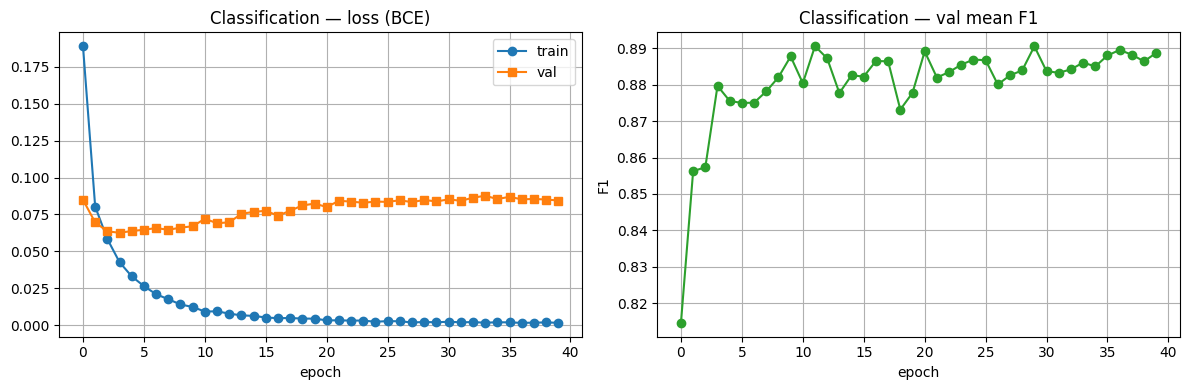

In [12]:
# --- Classification training curves ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(cls_hist['train_loss'], 'o-', label='train')
ax[0].plot(cls_hist['val_loss'],   's-', label='val')
ax[0].set_title('Classification — loss (BCE)'); ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(cls_hist['val_f1'], 'o-', color='tab:green')
ax[1].set_title('Classification — val mean F1'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('F1'); ax[1].grid(True)
plt.tight_layout(); plt.show()


---
## Part 2B — Semantic Segmentation

ResNet-50 encoder + ASPP + custom U-Net decoder + auxiliary head. CE + Dice loss.
Class-balanced sampler. Input 384, 50 epochs, multi-scale + flip TTA at inference.


In [13]:
# ---------- Segmentation Dataset (albumentations — handles image+mask) ----------
train_tf_seg = A.Compose([
    A.LongestMaxSize(max_size=int(IMG_SIZE_SEG*1.25)),
    A.PadIfNeeded(min_height=IMG_SIZE_SEG, min_width=IMG_SIZE_SEG, border_mode=0, fill_mask=IGNORE_IDX),
    A.RandomResizedCrop(size=(IMG_SIZE_SEG, IMG_SIZE_SEG), scale=(0.6,1.0)),
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.9,1.1), rotate=(-10,10), translate_percent=(-0.05,0.05), border_mode=0, p=0.3),
    A.ColorJitter(0.2,0.2,0.2,0.05, p=0.5),
    A.Normalize(mean=MEAN, std=STD), ToTensorV2(),
])
val_tf_seg = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE_SEG),
    A.PadIfNeeded(min_height=IMG_SIZE_SEG, min_width=IMG_SIZE_SEG, border_mode=0, fill_mask=IGNORE_IDX),
    A.Normalize(mean=MEAN, std=STD), ToTensorV2(),
])

class SegDataset(Dataset):
    def __init__(self, ids, tf):
        self.ids = ids; self.tf = tf
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        iid = self.ids[i]
        img = np.array(Image.open(TRAIN_IMG/f'{iid}.jpg').convert('RGB'))
        msk = np.array(Image.open(TRAIN_MSK/f'{iid}.png'))
        out = self.tf(image=img, mask=msk)
        return out['image'], out['mask'].long()

mask_ids = {p.stem for p in TRAIN_MSK.glob('*.png')}
seg_train_ids = [i for i in train_ids if i in mask_ids]
seg_val_ids   = [i for i in val_ids   if i in mask_ids]
print('seg train/val:', len(seg_train_ids), len(seg_val_ids))


seg train/val: 1870 330


In [14]:
# ---------- Class-balanced sampler ----------
def sample_weights(ids):
    counts = np.zeros(SEG_CLASSES, dtype=np.float64)
    per_img = []
    for iid in ids:
        m = np.array(Image.open(TRAIN_MSK/f'{iid}.png'))
        u, c = np.unique(m, return_counts=True)
        present = set(int(v) for v in u if v != 0 and v != IGNORE_IDX)
        per_img.append(present)
        for v, cc in zip(u, c):
            if v == IGNORE_IDX: continue
            counts[int(v)] += cc
    freq = counts / counts.sum()
    inv  = 1.0 / np.sqrt(freq + 1e-6)
    w = []
    for present in per_img:
        w.append(max((inv[c] for c in present), default=1.0))
    return torch.tensor(w, dtype=torch.double)

sw = sample_weights(seg_train_ids)
sampler = WeightedRandomSampler(sw, num_samples=len(sw), replacement=True, generator=g)

seg_train_ld = DataLoader(SegDataset(seg_train_ids, train_tf_seg), batch_size=BATCH_SEG,
                          sampler=sampler, num_workers=2, pin_memory=True,
                          worker_init_fn=seed_worker, generator=g)
seg_val_ld   = DataLoader(SegDataset(seg_val_ids, val_tf_seg), batch_size=BATCH_SEG,
                          shuffle=False, num_workers=2, pin_memory=True,
                          worker_init_fn=seed_worker, generator=g)


In [15]:
# ---------- Segmentation Model: ResNet-50 + ASPP + U-Net decoder ----------
class ConvBlock(nn.Module):
    def __init__(self, cin, cout, k=3, d=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, k, padding=d, dilation=d, bias=False),
            nn.BatchNorm2d(cout), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class ASPP(nn.Module):
    def __init__(self, cin, cout=256, rates=(1,6,12,18)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(nn.Conv2d(cin, cout, 1 if r==1 else 3, padding=0 if r==1 else r, dilation=r, bias=False),
                          nn.BatchNorm2d(cout), nn.ReLU(inplace=True)) for r in rates])
        self.gp = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(cin, cout, 1, bias=False),
                                nn.BatchNorm2d(cout), nn.ReLU(inplace=True))
        self.proj = nn.Sequential(nn.Conv2d(cout*(len(rates)+1), cout, 1, bias=False),
                                  nn.BatchNorm2d(cout), nn.ReLU(inplace=True), nn.Dropout2d(0.1))
    def forward(self, x):
        feats = [b(x) for b in self.branches]
        gp = F.interpolate(self.gp(x), size=x.shape[-2:], mode='bilinear', align_corners=False)
        return self.proj(torch.cat(feats+[gp], dim=1))

class UpBlock(nn.Module):
    def __init__(self, cin, cskip, cout):
        super().__init__()
        self.reduce = nn.Conv2d(cin, cout, 1)
        self.skip   = nn.Conv2d(cskip, cout, 1)
        self.conv   = nn.Sequential(ConvBlock(cout*2, cout), ConvBlock(cout, cout))
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([self.reduce(x), self.skip(skip)], dim=1))

class SegNet(nn.Module):
    def __init__(self, num_classes=SEG_CLASSES, pretrained=True):
        super().__init__()
        w = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        bb = resnet50(weights=w)
        self.stem=nn.Sequential(bb.conv1, bb.bn1, bb.relu); self.pool=bb.maxpool
        self.layer1=bb.layer1; self.layer2=bb.layer2; self.layer3=bb.layer3; self.layer4=bb.layer4
        self.aspp = ASPP(2048, 256)
        self.up4 = UpBlock(256, 1024, 256); self.up3 = UpBlock(256, 512, 128)
        self.up2 = UpBlock(128, 256, 64);   self.up1 = UpBlock(64, 64, 64)
        self.final = nn.Sequential(ConvBlock(64, 64), nn.Conv2d(64, num_classes, 1))
        self.aux = nn.Sequential(nn.Conv2d(1024, 256, 3, padding=1, bias=False),
                                 nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout2d(0.1),
                                 nn.Conv2d(256, num_classes, 1))
    def forward(self, x):
        H,W = x.shape[-2:]
        s1 = self.stem(x); p = self.pool(s1)
        c2 = self.layer1(p); c3 = self.layer2(c2); c4 = self.layer3(c3); c5 = self.layer4(c4)
        f = self.aspp(c5)
        d4 = self.up4(f, c4); d3 = self.up3(d4, c3); d2 = self.up2(d3, c2); d1 = self.up1(d2, s1)
        out = F.interpolate(self.final(d1), size=(H,W), mode='bilinear', align_corners=False)
        if self.training:
            aux = F.interpolate(self.aux(c4), size=(H,W), mode='bilinear', align_corners=False)
            return out, aux
        return out

model_seg = SegNet().to(device)
print('SegNet: %.2fM params' % (sum(p.numel() for p in model_seg.parameters())/1e6))


SegNet: 44.34M params


In [16]:
# ---------- Losses + metrics ----------
def dice_loss(logits, target, ignore_index=IGNORE_IDX, eps=1e-6):
    C = logits.shape[1]; valid = (target != ignore_index)
    t = target.clone(); t[~valid] = 0
    t_oh = F.one_hot(t, C).permute(0,3,1,2).float()
    p = F.softmax(logits, dim=1); mask = valid.unsqueeze(1).float()
    p = p*mask; t_oh = t_oh*mask
    inter = (p*t_oh).sum(dim=(0,2,3)); denom = p.sum(dim=(0,2,3)) + t_oh.sum(dim=(0,2,3))
    return 1 - ((2*inter+eps)/(denom+eps)).mean()

ce = nn.CrossEntropyLoss(ignore_index=IGNORE_IDX)
def seg_loss(out, target, aux=None):
    L = ce(out, target) + 0.5*dice_loss(out, target)
    if aux is not None: L += 0.4*(ce(aux, target) + 0.5*dice_loss(aux, target))
    return L

def confmat(pred, target, C=SEG_CLASSES):
    k = (target != IGNORE_IDX) & (target < C)
    idx = C*target[k].to(torch.int64) + pred[k].to(torch.int64)
    return torch.bincount(idx, minlength=C*C).view(C, C)

def miou_from(cm):
    tp = torch.diag(cm).float(); fp = cm.sum(0).float()-tp; fn = cm.sum(1).float()-tp
    iou = tp/(tp+fp+fn+1e-9); present = cm.sum(1) > 0
    return iou[present].mean().item(), iou


In [17]:
# ---------- Train Segmentation ----------
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

opt_seg   = AdamW(model_seg.parameters(), lr=LR_SEG, weight_decay=1e-4)
sched_seg = CosineAnnealingLR(opt_seg, T_max=EPOCHS_SEG)

seg_hist = {'train_loss': [], 'val_miou': []}
best_miou = 0.0

for epoch in range(1, EPOCHS_SEG + 1):
    model_seg.train(); tl=0; n=0
    for imgs, msks in seg_train_ld:
        imgs=imgs.to(device); msks=msks.to(device)
        out, aux = model_seg(imgs)
        loss = seg_loss(out, msks, aux)
        opt_seg.zero_grad(); loss.backward(); opt_seg.step()
        tl += loss.item()*imgs.size(0); n += imgs.size(0)
    sched_seg.step()

    model_seg.eval(); cm = torch.zeros(SEG_CLASSES, SEG_CLASSES, device=device)
    with torch.no_grad():
        for imgs, msks in seg_val_ld:
            imgs=imgs.to(device); msks=msks.to(device)
            cm += confmat(model_seg(imgs).argmax(1), msks)
    miou, iou = miou_from(cm.cpu())
    seg_hist['train_loss'].append(tl/n); seg_hist['val_miou'].append(miou)
    tag = ''
    if miou > best_miou:
        best_miou = miou
        torch.save(model_seg.state_dict(), SEG_W/'segmenter.pth')
        tag = f'  -> saved (mIoU {best_miou:.4f})'
    print(f'ep {epoch:02d}/{EPOCHS_SEG} | loss {tl/n:.4f} | val mIoU {miou:.4f}{tag}')

print(f'best val mIoU: {best_miou:.4f}')


/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:3504: UserWarning: nll_loss2d_forward_out_cuda_template does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return torch._C._nn.cross_entropy_loss(


ep 01/50 | loss 2.6327 | val mIoU 0.0537  -> saved (mIoU 0.0537)
ep 02/50 | loss 1.9137 | val mIoU 0.1650  -> saved (mIoU 0.1650)
ep 03/50 | loss 1.6515 | val mIoU 0.1559
ep 04/50 | loss 1.5575 | val mIoU 0.1871  -> saved (mIoU 0.1871)
ep 05/50 | loss 1.4450 | val mIoU 0.2781  -> saved (mIoU 0.2781)
ep 06/50 | loss 1.3910 | val mIoU 0.2667
ep 07/50 | loss 1.3630 | val mIoU 0.3200  -> saved (mIoU 0.3200)
ep 08/50 | loss 1.2531 | val mIoU 0.3488  -> saved (mIoU 0.3488)
ep 09/50 | loss 1.1936 | val mIoU 0.4386  -> saved (mIoU 0.4386)
ep 10/50 | loss 1.1416 | val mIoU 0.3550
ep 11/50 | loss 1.1277 | val mIoU 0.4339
ep 12/50 | loss 1.0462 | val mIoU 0.4307
ep 13/50 | loss 1.0213 | val mIoU 0.4761  -> saved (mIoU 0.4761)
ep 14/50 | loss 0.9505 | val mIoU 0.4962  -> saved (mIoU 0.4962)
ep 15/50 | loss 0.8993 | val mIoU 0.5024  -> saved (mIoU 0.5024)
ep 16/50 | loss 0.8734 | val mIoU 0.5011
ep 17/50 | loss 0.8347 | val mIoU 0.5120  -> saved (mIoU 0.5120)
ep 18/50 | loss 0.7852 | val mIoU 0.522

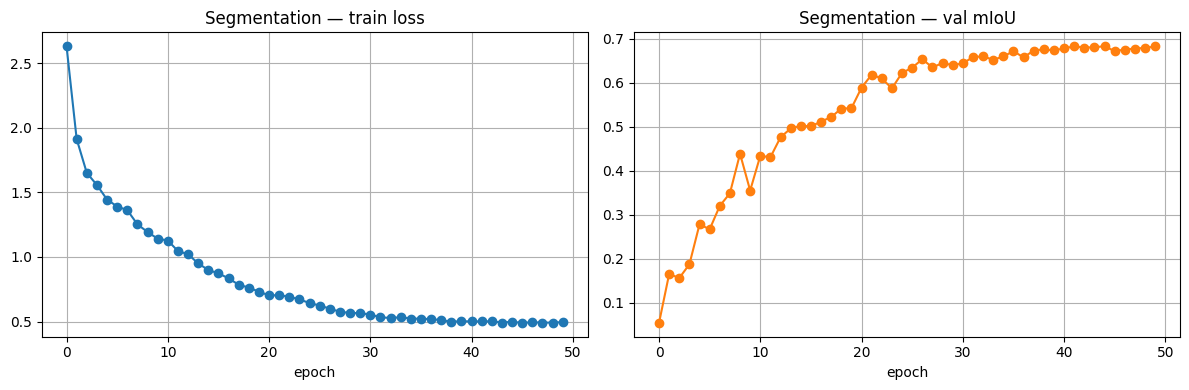

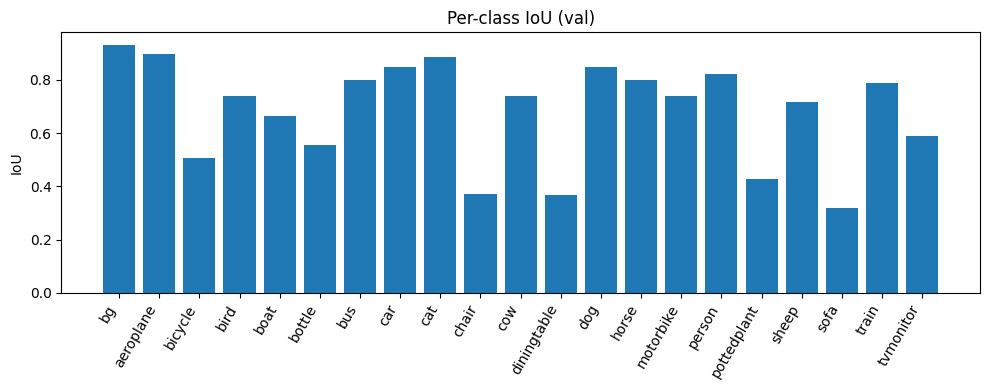

In [18]:
# --- Segmentation training curves + per-class IoU ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(seg_hist['train_loss'], 'o-'); ax[0].set_title('Segmentation — train loss'); ax[0].set_xlabel('epoch'); ax[0].grid(True)
ax[1].plot(seg_hist['val_miou'], 'o-', color='tab:orange'); ax[1].set_title('Segmentation — val mIoU'); ax[1].set_xlabel('epoch'); ax[1].grid(True)
plt.tight_layout(); plt.show()

# Per-class IoU bar chart (best weights)
model_seg.load_state_dict(torch.load(SEG_W/'segmenter.pth', map_location=device))
model_seg.eval(); cm = torch.zeros(SEG_CLASSES, SEG_CLASSES, device=device)
with torch.no_grad():
    for imgs, msks in seg_val_ld:
        imgs=imgs.to(device); msks=msks.to(device)
        cm += confmat(model_seg(imgs).argmax(1), msks)
_, iou = miou_from(cm.cpu())
plt.figure(figsize=(10,4))
plt.bar(['bg']+CLASSES, iou.numpy()); plt.xticks(rotation=60, ha='right')
plt.ylabel('IoU'); plt.title('Per-class IoU (val)'); plt.tight_layout(); plt.show()


---
## Part 2B (ii) — Segmentation Model B (ResNet-18 + simple U-Net)

For the mandatory **Wilcoxon signed-rank test** in Part 3 we need **two different segmentation models** evaluated on the same val split. Model A (above) uses ResNet-50 + ASPP; Model B below uses a lighter **ResNet-18 encoder + simple U-Net decoder** (no ASPP, no aux head).

Both sets of weights are saved to `segmentation/weights/` so that `statistical_tests.ipynb` can load them without retraining.

In [19]:
# ---------- Model B: ResNet-18 encoder + simple U-Net decoder (no ASPP) ----------
from torchvision.models import resnet18, ResNet18_Weights

class ConvBlock_B(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1, bias=False),
            nn.BatchNorm2d(cout), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class UpBlock_B(nn.Module):
    def __init__(self, cin, cskip, cout):
        super().__init__()
        self.up   = nn.Conv2d(cin, cout, 1)
        self.conv = ConvBlock_B(cout + cskip, cout)
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([self.up(x), skip], dim=1))

class SegNetB(nn.Module):
    """ResNet-18 encoder + simple U-Net decoder (different family from Model A)."""
    def __init__(self, num_classes=SEG_CLASSES, pretrained=True):
        super().__init__()
        w = ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        bb = resnet18(weights=w)
        self.stem   = nn.Sequential(bb.conv1, bb.bn1, bb.relu)   # 1/2, 64
        self.pool   = bb.maxpool
        self.layer1 = bb.layer1     # 1/4,  64
        self.layer2 = bb.layer2     # 1/8,  128
        self.layer3 = bb.layer3     # 1/16, 256
        self.layer4 = bb.layer4     # 1/32, 512
        self.up4 = UpBlock_B(512, 256, 256)
        self.up3 = UpBlock_B(256, 128, 128)
        self.up2 = UpBlock_B(128,  64,  64)
        self.up1 = UpBlock_B( 64,  64,  64)
        self.final = nn.Sequential(ConvBlock_B(64, 64), nn.Conv2d(64, num_classes, 1))

    def forward(self, x):
        H, W = x.shape[-2:]
        s1 = self.stem(x); p = self.pool(s1)
        c2 = self.layer1(p); c3 = self.layer2(c2)
        c4 = self.layer3(c3); c5 = self.layer4(c4)
        d4 = self.up4(c5, c4); d3 = self.up3(d4, c3)
        d2 = self.up2(d3, c2); d1 = self.up1(d2, s1)
        return F.interpolate(self.final(d1), size=(H, W), mode='bilinear', align_corners=False)

model_B = SegNetB().to(device)
print('SegNetB (ResNet-18): %.2fM params' % (sum(p.numel() for p in model_B.parameters())/1e6))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


SegNetB (ResNet-18): 13.86M params


In [20]:
# ---------- Train Model B (same loss, same data, same schedule) ----------
EPOCHS_SEG_B = 20     # shorter than Model A — lighter model converges faster

# CE only (no aux for model B, simple architecture)
def seg_loss_simple(out, target):
    return ce(out, target) + 0.5*dice_loss(out, target)

opt_B   = AdamW(model_B.parameters(), lr=LR_SEG, weight_decay=1e-4)
sched_B = CosineAnnealingLR(opt_B, T_max=EPOCHS_SEG_B)

seg_B_hist = {'train_loss': [], 'val_miou': []}
best_miou_B = 0.0

for epoch in range(1, EPOCHS_SEG_B + 1):
    model_B.train(); tl=0; n=0
    for imgs, msks in seg_train_ld:
        imgs=imgs.to(device); msks=msks.to(device)
        logits = model_B(imgs)
        loss = seg_loss_simple(logits, msks)
        opt_B.zero_grad(); loss.backward(); opt_B.step()
        tl += loss.item()*imgs.size(0); n += imgs.size(0)
    sched_B.step()

    model_B.eval(); cm = torch.zeros(SEG_CLASSES, SEG_CLASSES, device=device)
    with torch.no_grad():
        for imgs, msks in seg_val_ld:
            imgs=imgs.to(device); msks=msks.to(device)
            cm += confmat(model_B(imgs).argmax(1), msks)
    miou, _ = miou_from(cm.cpu())
    seg_B_hist['train_loss'].append(tl/n); seg_B_hist['val_miou'].append(miou)
    tag = ''
    if miou > best_miou_B:
        best_miou_B = miou
        torch.save(model_B.state_dict(), SEG_W / 'segmenter_B.pth')
        tag = f'  -> saved (mIoU {best_miou_B:.4f})'
    print(f'[B] ep {epoch:02d}/{EPOCHS_SEG_B} | loss {tl/n:.4f} | val mIoU {miou:.4f}{tag}')

print(f'Model B best val mIoU: {best_miou_B:.4f}')

[B] ep 01/30 | loss 2.0766 | val mIoU 0.0909  -> saved (mIoU 0.0909)
[B] ep 02/30 | loss 1.5166 | val mIoU 0.1024  -> saved (mIoU 0.1024)
[B] ep 03/30 | loss 1.4036 | val mIoU 0.1072  -> saved (mIoU 0.1072)
[B] ep 04/30 | loss 1.3214 | val mIoU 0.1113  -> saved (mIoU 0.1113)
[B] ep 05/30 | loss 1.3249 | val mIoU 0.1437  -> saved (mIoU 0.1437)
[B] ep 06/30 | loss 1.2360 | val mIoU 0.1595  -> saved (mIoU 0.1595)
[B] ep 07/30 | loss 1.1816 | val mIoU 0.1742  -> saved (mIoU 0.1742)
[B] ep 08/30 | loss 1.1478 | val mIoU 0.2126  -> saved (mIoU 0.2126)
[B] ep 09/30 | loss 1.0571 | val mIoU 0.2580  -> saved (mIoU 0.2580)
[B] ep 10/30 | loss 1.0629 | val mIoU 0.2446
[B] ep 11/30 | loss 1.0612 | val mIoU 0.2772  -> saved (mIoU 0.2772)
[B] ep 12/30 | loss 0.9904 | val mIoU 0.3464  -> saved (mIoU 0.3464)
[B] ep 13/30 | loss 0.9419 | val mIoU 0.3372
[B] ep 14/30 | loss 0.8935 | val mIoU 0.3829  -> saved (mIoU 0.3829)
[B] ep 15/30 | loss 0.8476 | val mIoU 0.3729
[B] ep 16/30 | loss 0.8195 | val mIoU

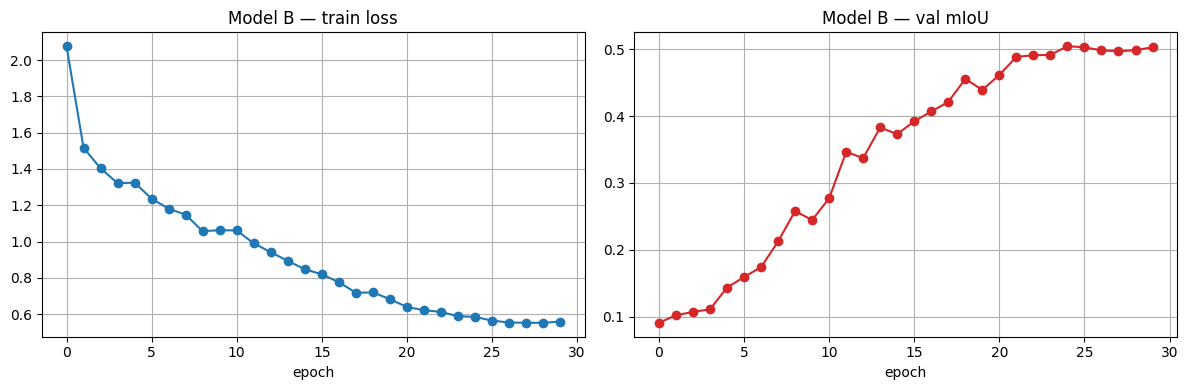


Summary:  Model A best mIoU = 0.6835  |  Model B best mIoU = 0.5044
Weights saved:
  segmentation/weights/segmenter.pth   (Model A — ResNet50+ASPP)
  segmentation/weights/segmenter_B.pth (Model B — ResNet18+UNet)


In [21]:
# --- Model B training curves ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(seg_B_hist['train_loss'], 'o-'); ax[0].set_title('Model B — train loss'); ax[0].set_xlabel('epoch'); ax[0].grid(True)
ax[1].plot(seg_B_hist['val_miou'], 'o-', color='tab:red'); ax[1].set_title('Model B — val mIoU'); ax[1].set_xlabel('epoch'); ax[1].grid(True)
plt.tight_layout(); plt.show()

print(f'\nSummary:  Model A best mIoU = {best_miou:.4f}  |  Model B best mIoU = {best_miou_B:.4f}')
print(f'Weights saved:')
print(f'  segmentation/weights/segmenter.pth   (Model A — ResNet50+ASPP)')
print(f'  segmentation/weights/segmenter_B.pth (Model B — ResNet18+UNet)')

---
## Write `classification/model.py` and `segmentation/model.py`


In [22]:
# ---------- classification/model.py ----------
CLS_MODEL_PY = """\
\"\"\"
classification/model.py — evaluator wrapper
\"\"\"
from __future__ import annotations
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms as T
from torchvision import models as tvm

CLASSES = ["aeroplane","bicycle","bird","boat","bottle","bus","car","cat",
           "chair","cow","diningtable","dog","horse","motorbike","person",
           "pottedplant","sheep","sofa","train","tvmonitor"]
NUM_CLASSES = 20
MEAN = (0.485, 0.456, 0.406); STD = (0.229, 0.224, 0.225)
_IMG = 224


class ClfHead(nn.Module):
    def __init__(self, in_f=2048, hidden=512, n=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(in_f, hidden),
            nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(hidden, n))
    def forward(self, x): return torch.sigmoid(self.net(x))


class ClfModel(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        w = tvm.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        bb = tvm.resnet50(weights=w)
        self.backbone = nn.Sequential(*list(bb.children())[:-1])
        self.head = ClfHead()
    def forward(self, x): return self.head(self.backbone(x).flatten(1))


class ClassificationModel:
    def __init__(self, weights_dir: str):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = ClfModel(pretrained=False)
        weights_dir = str(weights_dir)
        ck = os.path.join(weights_dir, "classifier.pth")
        if not os.path.isfile(ck):
            pth = sorted(f for f in os.listdir(weights_dir) if f.endswith(".pth"))
            if not pth: raise FileNotFoundError(f"No .pth in {weights_dir}")
            ck = os.path.join(weights_dir, pth[0])
        state = torch.load(ck, map_location=self.device)
        if isinstance(state, dict) and "state_dict" in state: state = state["state_dict"]
        self.model.load_state_dict(state, strict=True)
        self.model.to(self.device).eval()
        self.tf = T.Compose([T.Resize((_IMG, _IMG)), T.ToTensor(), T.Normalize(mean=MEAN, std=STD)])

    @torch.no_grad()
    def predict(self, image: np.ndarray) -> dict:
        if image.dtype != np.uint8: image = image.astype(np.uint8)
        if image.ndim == 2: image = np.stack([image]*3, -1)
        if image.shape[-1] == 4: image = image[..., :3]
        pil = Image.fromarray(image).convert("RGB")
        x = self.tf(pil).unsqueeze(0).to(self.device)
        p = self.model(x)[0].cpu().numpy()
        return {CLASSES[i]: float(p[i]) for i in range(NUM_CLASSES)}
"""

(CLS_DIR / 'model.py').write_text(CLS_MODEL_PY)
print('wrote', CLS_DIR / 'model.py')


wrote classification/model.py


In [23]:
# ---------- segmentation/model.py ----------
SEG_MODEL_PY = """\
\"\"\"
segmentation/model.py — evaluator wrapper
\"\"\"
from __future__ import annotations
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights

NUM_CLASSES = 21
_MEAN = np.array([0.485,0.456,0.406], dtype=np.float32)
_STD  = np.array([0.229,0.224,0.225], dtype=np.float32)
_IMG  = 384


class ConvBlock(nn.Module):
    def __init__(self, cin, cout, k=3, d=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, cout, k, padding=d, dilation=d, bias=False),
            nn.BatchNorm2d(cout), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class ASPP(nn.Module):
    def __init__(self, cin, cout=256, rates=(1,6,12,18)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(nn.Conv2d(cin, cout, 1 if r==1 else 3, padding=0 if r==1 else r, dilation=r, bias=False),
                          nn.BatchNorm2d(cout), nn.ReLU(inplace=True)) for r in rates])
        self.gp = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(cin, cout, 1, bias=False),
                                nn.BatchNorm2d(cout), nn.ReLU(inplace=True))
        self.proj = nn.Sequential(nn.Conv2d(cout*(len(rates)+1), cout, 1, bias=False),
                                  nn.BatchNorm2d(cout), nn.ReLU(inplace=True), nn.Dropout2d(0.1))
    def forward(self, x):
        feats = [b(x) for b in self.branches]
        gp = F.interpolate(self.gp(x), size=x.shape[-2:], mode="bilinear", align_corners=False)
        return self.proj(torch.cat(feats+[gp], dim=1))

class UpBlock(nn.Module):
    def __init__(self, cin, cskip, cout):
        super().__init__()
        self.reduce = nn.Conv2d(cin, cout, 1)
        self.skip   = nn.Conv2d(cskip, cout, 1)
        self.conv = nn.Sequential(ConvBlock(cout*2, cout), ConvBlock(cout, cout))
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([self.reduce(x), self.skip(skip)], dim=1))

class SegNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=False):
        super().__init__()
        w = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        bb = resnet50(weights=w)
        self.stem=nn.Sequential(bb.conv1, bb.bn1, bb.relu); self.pool=bb.maxpool
        self.layer1=bb.layer1; self.layer2=bb.layer2; self.layer3=bb.layer3; self.layer4=bb.layer4
        self.aspp = ASPP(2048, 256)
        self.up4 = UpBlock(256, 1024, 256); self.up3 = UpBlock(256, 512, 128)
        self.up2 = UpBlock(128, 256, 64);   self.up1 = UpBlock(64, 64, 64)
        self.final = nn.Sequential(ConvBlock(64, 64), nn.Conv2d(64, num_classes, 1))
        self.aux = nn.Sequential(nn.Conv2d(1024, 256, 3, padding=1, bias=False),
                                 nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.Dropout2d(0.1),
                                 nn.Conv2d(256, num_classes, 1))
    def forward(self, x):
        H,W = x.shape[-2:]
        s1 = self.stem(x); p = self.pool(s1)
        c2 = self.layer1(p); c3 = self.layer2(c2); c4 = self.layer3(c3); c5 = self.layer4(c4)
        f = self.aspp(c5)
        d4 = self.up4(f, c4); d3 = self.up3(d4, c3); d2 = self.up2(d3, c2); d1 = self.up1(d2, s1)
        return F.interpolate(self.final(d1), size=(H,W), mode="bilinear", align_corners=False)


class SegmentationModel:
    def __init__(self, weights_dir: str):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = SegNet(pretrained=False)
        weights_dir = str(weights_dir)
        ck = os.path.join(weights_dir, "segmenter.pth")
        if not os.path.isfile(ck):
            pth = sorted(f for f in os.listdir(weights_dir) if f.endswith(".pth"))
            if not pth: raise FileNotFoundError(f"No .pth in {weights_dir}")
            ck = os.path.join(weights_dir, pth[0])
        state = torch.load(ck, map_location=self.device)
        if isinstance(state, dict) and "state_dict" in state: state = state["state_dict"]
        self.model.load_state_dict(state, strict=True)
        self.model.to(self.device).eval()

    @staticmethod
    def _prep(image, size=_IMG):
        if image.dtype != np.uint8: image = image.astype(np.uint8)
        if image.ndim == 2: image = np.stack([image]*3, -1)
        if image.shape[-1] == 4: image = image[..., :3]
        H, W = image.shape[:2]
        s = size / max(H, W); nh, nw = int(round(H*s)), int(round(W*s))
        pil = Image.fromarray(image).resize((nw, nh), Image.BILINEAR)
        canv = Image.new("RGB", (size, size), (0,0,0))
        px, py = (size-nw)//2, (size-nh)//2
        canv.paste(pil, (px, py))
        a = (np.asarray(canv, dtype=np.float32)/255.0 - _MEAN) / _STD
        return torch.from_numpy(a.transpose(2,0,1)).float().unsqueeze(0), (H,W,px,py,nw,nh)

    @torch.no_grad()
    def predict(self, image: np.ndarray) -> np.ndarray:
        if image.ndim == 2: image = np.stack([image]*3, -1)
        H, W = image.shape[:2]; probs = None
        for size in (_IMG, int(_IMG*1.25)):
            for flip in (False, True):
                x, info = self._prep(image, size)
                _,_,px,py,nw,nh = info; x = x.to(self.device)
                if flip: x = torch.flip(x, [3])
                p = F.softmax(self.model(x), dim=1)
                if flip: p = torch.flip(p, [3])
                p = p[:,:,py:py+nh,px:px+nw]
                p = F.interpolate(p, size=(H,W), mode="bilinear", align_corners=False)
                probs = p if probs is None else probs+p
        return probs.argmax(1)[0].cpu().numpy().astype(np.uint8)
"""

(SEG_DIR / 'model.py').write_text(SEG_MODEL_PY)
print('wrote', SEG_DIR / 'model.py')


wrote segmentation/model.py


---
## Submission CSV

Uses the exact `mask_to_rle` / `rle_to_mask` from SUBMISSION_README.md. Masks are resized to original image dims before encoding.


In [24]:
# ---- RLE (verbatim from SUBMISSION_README.md) ----
def mask_to_rle(mask: np.ndarray) -> str:
    flat = mask.flatten()
    starts, lengths, values = [], [], []
    i = 0
    while i < len(flat):
        if flat[i] != 0:
            start = i; val = flat[i]
            while i < len(flat) and flat[i] == val: i += 1
            starts.append(start); lengths.append(i-start); values.append(val)
        else:
            i += 1
    parts = []
    for s, l, v in zip(starts, lengths, values):
        parts.extend([str(s), str(l), str(int(v))])
    return ' '.join(parts) if parts else '0 0 0'

def rle_to_mask(rle_string: str, height: int, width: int) -> np.ndarray:
    mask = np.zeros(height*width, dtype=np.uint8)
    parts = list(map(int, rle_string.split()))
    for i in range(0, len(parts), 3):
        start, length, value = parts[i], parts[i+1], parts[i+2]
        mask[start:start+length] = value
    return mask.reshape(height, width)


In [25]:
# ---- TTA inference helpers ----
def letterbox_tensor(img, size):
    H, W = img.shape[:2]; s = size/max(H,W)
    nh, nw = int(round(H*s)), int(round(W*s))
    pil = Image.fromarray(img).resize((nw, nh), Image.BILINEAR)
    canv = Image.new('RGB', (size, size), (0,0,0))
    px, py = (size-nw)//2, (size-nh)//2
    canv.paste(pil, (px, py))
    a = (np.asarray(canv, dtype=np.float32)/255.0 - np.array(MEAN, np.float32))/np.array(STD, np.float32)
    return torch.from_numpy(a.transpose(2,0,1)).float().unsqueeze(0), (H,W,px,py,nw,nh)

@torch.no_grad()
def seg_predict_tta(img):
    H, W = img.shape[:2]; probs = None
    for size in (IMG_SIZE_SEG, int(IMG_SIZE_SEG*1.25)):
        for flip in (False, True):
            x, info = letterbox_tensor(img, size)
            _,_,px,py,nw,nh = info; x = x.to(device)
            if flip: x = torch.flip(x, [3])
            p = F.softmax(model_seg(x), dim=1)
            if flip: p = torch.flip(p, [3])
            p = p[:,:,py:py+nh,px:px+nw]
            p = F.interpolate(p, size=(H,W), mode='bilinear', align_corners=False)
            probs = p if probs is None else probs+p
    return probs.argmax(1)[0].cpu().numpy().astype(np.uint8)

cls_tf_infer = T.Compose([T.Resize((IMG_SIZE_CLS, IMG_SIZE_CLS)), T.ToTensor(), T.Normalize(mean=MEAN, std=STD)])

@torch.no_grad()
def cls_predict(img):
    pil = Image.fromarray(img).convert('RGB')
    x = cls_tf_infer(pil).unsqueeze(0).to(device)
    return model_cls(x)[0].cpu().numpy()     # already sigmoid probs


In [26]:
# ---- Generate submission.csv ----
model_cls.load_state_dict(torch.load(CLS_W/'classifier.pth', map_location=device))
model_seg.load_state_dict(torch.load(SEG_W/'segmenter.pth',  map_location=device))
model_cls.eval(); model_seg.eval()

rows = []
test_files = sorted(f for f in os.listdir(TEST_IMG) if f.lower().endswith('.jpg'))
for idx, fn in enumerate(test_files):
    iid = Path(fn).stem
    img = np.array(Image.open(TEST_IMG/fn).convert('RGB'))

    # classification
    prob = cls_predict(img)
    present = [CLASSES[k] for k, p in enumerate(prob) if p >= 0.5]
    cls_str = ' '.join(present) if present else 'background'

    # segmentation (TTA, output already matches original H x W)
    pred_mask = seg_predict_tta(img)
    rle = mask_to_rle(pred_mask)

    rows.append((iid, cls_str, rle))
    if (idx+1) % 100 == 0: print(f'{idx+1}/{len(test_files)}')

df = pd.DataFrame(rows, columns=['image_id','classification','segmentation_rle'])
df.to_csv('submission.csv', index=False)
print('Saved submission.csv —', len(df), 'rows')
df.head()


100/713
200/713
300/713
400/713
500/713
600/713
700/713
Saved submission.csv — 713 rows


,image_id,classification,segmentation_rle
0,img_00005,bicycle person,69204 14 15 69701 19 15 70200 22 15 70698 26 1...
1,img_00009,horse person,46100 1 13 46598 5 13 47098 7 13 47597 9 13 48...
2,img_00010,motorbike person,66767 7 14 67264 12 14 67762 16 14 68261 18 14...
3,img_00014,cat,28751 18 8 28778 13 8 29241 60 8 29736 91 8 30...
4,img_00015,horse person,31640 2 15 31952 13 15 32267 19 15 32584 22 15...
